# 🔬 Research Intelligence Agent
**Fine-tuned SciBERT for Scientific NER/RE + Knowledge Graph + Claim Verification**

Pipeline:
1. Fine-tune SciBERT on SciERC → NER + Relation Extraction
2. Search Agent (Semantic Scholar API) → fetch real papers
3. Build Knowledge Graph (networkx + pyvis)
4. Claim Verification with Qwen2.5-1.5B-Instruct
5. Benchmark on SciFact

**Timeline: 5 weeks | Dataset: SciERC → SciREX → SciFact**

# ⚙️ Install Dependencies

In [1]:
!pip install -q transformers datasets seqeval spacy pyvis networkx requests pymupdf accelerate
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 13.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 70.8 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 71.6 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import os, json, re, requests, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter, defaultdict
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    AutoModelForSequenceClassification, AutoModelForCausalLM,
    TrainingArguments, Trainer, DataCollatorForTokenClassification,
    pipeline
)
from datasets import load_dataset
from seqeval.metrics import classification_report, f1_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


---
# 📅 WEEK 1 — Foundation
**Goal:** Load SciERC, visualize data, PDF parser, spaCy baseline

## 1.1 Download & Load SciERC

In [31]:
import requests, zipfile, io, json
from pathlib import Path

SCIERC_DIR = Path('./scierc_data')
SCIERC_DIR.mkdir(exist_ok=True)

# Download từ trang gốc sciIE (Washington)
SCIERC_ZIP_URL = 'https://nlp.cs.washington.edu/sciIE/data/sciERC_processed.tar.gz'

def download_scierc():
    import tarfile
    fpath = SCIERC_DIR / 'sciERC_processed.tar.gz'
    if not fpath.exists():
        print('Downloading SciERC from nlp.cs.washington.edu...')
        r = requests.get(SCIERC_ZIP_URL, timeout=60, stream=True)
        r.raise_for_status()
        with open(fpath, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print('Download done. Extracting...')
    with tarfile.open(fpath, 'r:gz') as tar:
        tar.extractall(SCIERC_DIR)
    print('Extracted!')
    # List files để biết cấu trúc
    for p in sorted(SCIERC_DIR.rglob('*.json')):
        print(' ', p)

download_scierc()

Download done. Extracting...
Extracted!
  scierc_data/processed_data/json/dev.json
  scierc_data/processed_data/json/test.json
  scierc_data/processed_data/json/train.json


In [32]:
# Sau khi extract xong, tìm đúng path
import glob

json_files = sorted(glob.glob(str(SCIERC_DIR / '**/*.json'), recursive=True))
print('JSON files found:')
for f in json_files:
    print(' ', f)

JSON files found:
  scierc_data/processed_data/json/dev.json
  scierc_data/processed_data/json/test.json
  scierc_data/processed_data/json/train.json


In [33]:
# Load theo path thực tế sau extract
def load_jsonl(path):
    docs = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                docs.append(json.loads(line))
    return docs

# Thường extract ra dạng: scierc_data/processed_data/json/train.json
# Adjust path nếu cần sau khi chạy cell trên
BASE = SCIERC_DIR / 'processed_data' / 'json'

scierc = {
    'train': load_jsonl(BASE / 'train.json'),
    'dev':   load_jsonl(BASE / 'dev.json'),
    'test':  load_jsonl(BASE / 'test.json'),
}

print(f"train: {len(scierc['train'])}, dev: {len(scierc['dev'])}, test: {len(scierc['test'])}")
print('Sample keys:', list(scierc['train'][0].keys()))

train: 350, dev: 50, test: 100
Sample keys: ['clusters', 'sentences', 'ner', 'relations', 'doc_key']


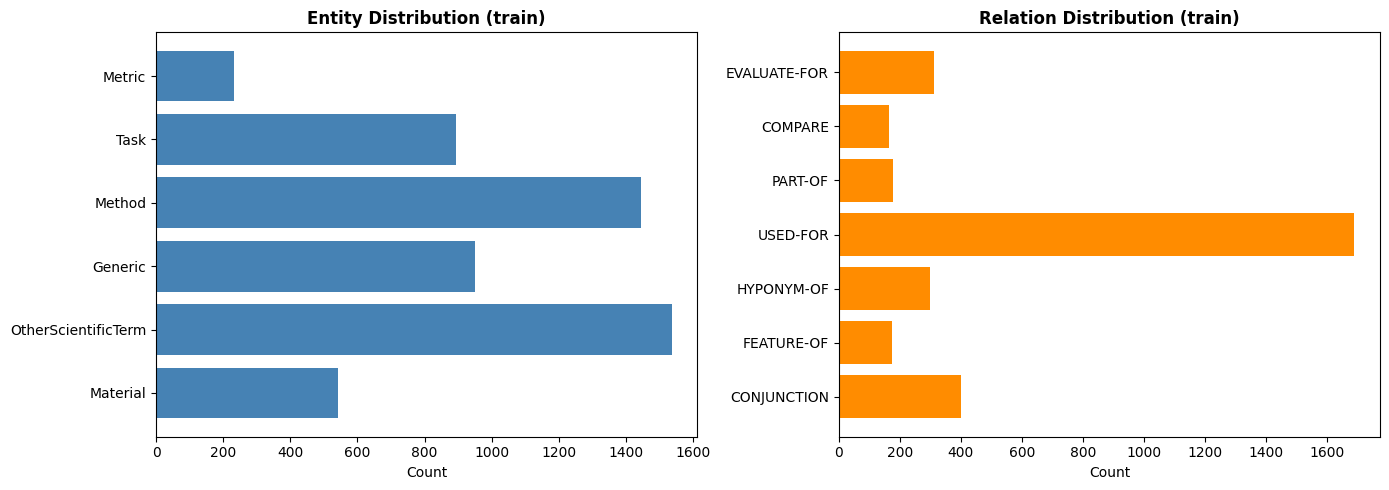

Entities: {'Material': 542, 'OtherScientificTerm': 1536, 'Generic': 950, 'Method': 1445, 'Task': 894, 'Metric': 231}
Relations: {'CONJUNCTION': 400, 'FEATURE-OF': 173, 'HYPONYM-OF': 298, 'USED-FOR': 1690, 'PART-OF': 179, 'COMPARE': 166, 'EVALUATE-FOR': 313}


In [34]:
# Visualize entity & relation distribution
ENTITY_TYPES = ['Method','Task','Metric','Material','Generic','OtherScientificTerm']
RELATION_TYPES = ['USED-FOR','FEATURE-OF','HYPONYM-OF','PART-OF','COMPARE','CONJUNCTION','EVALUATE-FOR']

def count_dist(docs, key):
    counts = Counter()
    for doc in docs:
        for sent_items in doc.get(key, []):
            for item in sent_items:
                if key == 'ner':
                    counts[item[2]] += 1
                elif key == 'relations':
                    counts[item[4]] += 1
    return counts

ent_counts = count_dist(scierc['train'], 'ner')
rel_counts  = count_dist(scierc['train'], 'relations')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(list(ent_counts.keys()), list(ent_counts.values()), color='steelblue')
axes[0].set_title('Entity Distribution (train)', fontweight='bold')
axes[0].set_xlabel('Count')
axes[1].barh(list(rel_counts.keys()), list(rel_counts.values()), color='darkorange')
axes[1].set_title('Relation Distribution (train)', fontweight='bold')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.savefig('entity_relation_dist.png', dpi=120)
plt.show()
print('Entities:', dict(ent_counts))
print('Relations:', dict(rel_counts))

## 1.2 PDF Parser (pymupdf)

In [35]:
import fitz  # pymupdf

def parse_pdf(pdf_path):
    """Extract text blocks and figure captions from a PDF."""
    doc = fitz.open(pdf_path)
    result = {'text': [], 'figure_captions': [], 'num_pages': len(doc)}
    caption_pattern = re.compile(r'(Figure|Fig\.|Table)\s*\d+[:\.]?', re.IGNORECASE)
    for page_num, page in enumerate(doc):
        blocks = page.get_text('blocks')
        for block in blocks:
            text = block[4].strip()
            if not text or len(text) < 10:
                continue
            if caption_pattern.search(text):
                result['figure_captions'].append({'page': page_num + 1, 'caption': text[:300]})
            else:
                result['text'].append(text)
    doc.close()
    result['full_text'] = ' '.join(result['text'])
    return result

# Usage example (comment out if no PDF available)
# parsed = parse_pdf('your_paper.pdf')
# print(f"Pages: {parsed['num_pages']}")
# print(f"Captions found: {len(parsed['figure_captions'])}")
# print(parsed['full_text'][:500])
print('PDF parser ready — call parse_pdf(path) on any paper PDF.')

PDF parser ready — call parse_pdf(path) on any paper PDF.


## 1.3 spaCy Baseline NER (F1 to beat)

In [36]:
import spacy
nlp = spacy.load('en_core_web_sm')

# Map spaCy labels → SciERC labels (rough approximation)
SPACY_TO_SCIERC = {'ORG': 'Method', 'PRODUCT': 'Method', 'WORK_OF_ART': 'Task',
                   'EVENT': 'Task', 'QUANTITY': 'Metric', 'PERCENT': 'Metric'}

def flatten_scierc_tokens_and_labels(docs, max_docs=50):
    samples = []
    for doc in docs[:max_docs]:
        tokens = [t for sent in doc['sentences'] for t in sent]
        labels = ['O'] * len(tokens)
        offset = 0
        for sent_idx, sent_ners in enumerate(doc.get('ner', [])):
            sent_len = len(doc['sentences'][sent_idx])
            for (start, end, etype) in sent_ners:
                s = start - offset
                e = end - offset
                for i in range(s, e + 1):
                    if 0 <= i < sent_len:
                        labels[offset + i] = f'B-{etype}' if i == s else f'I-{etype}'
            offset += sent_len
        samples.append((tokens, labels))
    return samples

test_samples = flatten_scierc_tokens_and_labels(scierc['test'], max_docs=50)

true_labels, pred_labels = [], []
for tokens, gold in test_samples:
    text = ' '.join(tokens)
    spacy_doc = nlp(text)
    pred = ['O'] * len(tokens)
    for ent in spacy_doc.ents:
        mapped = SPACY_TO_SCIERC.get(ent.label_, None)
        if mapped:
            # approximate token alignment
            char_start = ent.start_char
            running = 0
            for i, tok in enumerate(tokens):
                if running >= char_start:
                    pred[i] = f'B-{mapped}'
                    break
                running += len(tok) + 1
    true_labels.append(gold)
    pred_labels.append(pred)

baseline_f1 = f1_score(true_labels, pred_labels)
print(f'spaCy Baseline NER F1 (micro): {baseline_f1:.4f}')
print('→ SciBERT fine-tuned should beat this significantly.')

spaCy Baseline NER F1 (micro): 0.0068
→ SciBERT fine-tuned should beat this significantly.


---
# 📅 WEEK 2 — Train Extraction Model
**Goal:** Fine-tune SciBERT for NER + Relation Extraction on SciERC

## 2.1 Prepare NER Dataset (BIO tagging)

In [32]:
MODEL_NAME = 'allenai/scibert_scivocab_cased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Build label list
NER_LABELS = ['O'] + [f'{bio}-{et}' for et in ENTITY_TYPES for bio in ['B','I']]
label2id = {l: i for i, l in enumerate(NER_LABELS)}
id2label = {i: l for l, i in label2id.items()}
print(f'NER labels ({len(NER_LABELS)}):', NER_LABELS)

def scierc_to_bio(doc):
    """Convert one SciERC doc to list of (tokens, bio_labels) per sentence."""
    samples = []
    for sent_idx, sentence in enumerate(doc['sentences']):
        labels = ['O'] * len(sentence)
        for (start, end, etype) in doc.get('ner', [[]])[sent_idx] if sent_idx < len(doc.get('ner', [])) else []:
            local_s = start
            local_e = end
            # SciERC indices are doc-level; compute sentence-level offset
            offset = sum(len(doc['sentences'][i]) for i in range(sent_idx))
            ls = start - offset
            le = end - offset
            for i in range(ls, min(le + 1, len(labels))):
                labels[i] = f'B-{etype}' if i == ls else f'I-{etype}'
        samples.append({'tokens': sentence, 'ner_tags': labels})
    return samples

train_ner = [s for doc in scierc['train'] for s in scierc_to_bio(doc)]
dev_ner   = [s for doc in scierc['dev']   for s in scierc_to_bio(doc)]
test_ner  = [s for doc in scierc['test']  for s in scierc_to_bio(doc)]
print(f'NER samples — train: {len(train_ner)}, dev: {len(dev_ner)}, test: {len(test_ner)}')

NER labels (13): ['O', 'B-Method', 'I-Method', 'B-Task', 'I-Task', 'B-Metric', 'I-Metric', 'B-Material', 'I-Material', 'B-Generic', 'I-Generic', 'B-OtherScientificTerm', 'I-OtherScientificTerm']
NER samples — train: 1861, dev: 275, test: 551


In [34]:
class NERDataset(Dataset):
    def __init__(self, samples, tokenizer, label2id, max_len=256):
        self.samples = samples
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        tokens = sample['tokens']
        tags   = sample['ner_tags']
        enc = self.tokenizer(
            tokens, is_split_into_words=True,
            max_length=self.max_len, truncation=True, padding='max_length'
        )
        word_ids = enc.word_ids()
        label_ids = []
        prev_wid = None
        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)
            elif wid != prev_wid:
                label_ids.append(self.label2id.get(tags[wid], 0))
            else:
                tag = tags[wid]
                label_ids.append(self.label2id.get(tag.replace('B-','I-'), 0))
            prev_wid = wid
        enc['labels'] = label_ids
        return {k: torch.tensor(v) for k, v in enc.items()}

train_dataset = NERDataset(train_ner, tokenizer, label2id)
dev_dataset   = NERDataset(dev_ner,   tokenizer, label2id)
test_dataset  = NERDataset(test_ner,  tokenizer, label2id)
print('Datasets created. Sample input_ids shape:', train_dataset[0]['input_ids'].shape)

Datasets created. Sample input_ids shape: torch.Size([256])


## 2.2 Fine-tune SciBERT for NER

In [37]:
from seqeval.metrics import classification_report as seq_report

ner_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(NER_LABELS),
    id2label=id2label, label2id=label2id
)

def compute_metrics_ner(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_preds, true_labels = [], []
    for preds_row, labels_row in zip(predictions, labels):
        tp, tl = [], []
        for pred, label in zip(preds_row, labels_row):
            if label != -100:
                tp.append(id2label[pred])
                tl.append(id2label[label])
        true_preds.append(tp)
        true_labels.append(tl)
    return {'f1': f1_score(true_labels, true_preds)}

data_collator = DataCollatorForTokenClassification(tokenizer)

ner_training_args = TrainingArguments(
    output_dir='./ner_model',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    save_total_limit=1,
    metric_for_best_model='f1',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

ner_trainer = Trainer(
    model=ner_model,
    args=ner_training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_ner,
)

print('Starting NER fine-tuning...')
ner_trainer.train()
print('Training done!')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: allenai/scibert_scivocab_cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored wh

Starting NER fine-tuning...


Epoch,Training Loss,Validation Loss,F1
1,3.803472,1.954005,0.152815
2,1.558842,1.073894,0.492721
3,0.913343,0.902100,0.568207
4,0.681879,0.901498,0.585256
5,0.553291,0.924374,0.587310


Error during conversion: AttributeError("'str' object has no attribute 'decode'")


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training done!


In [38]:
# Evaluate on test set
test_results = ner_trainer.evaluate(test_dataset)
print(f"\n{'='*50}")
print(f"NER Test F1: {test_results['eval_f1']:.4f}")
print(f"Baseline F1: {baseline_f1:.4f}")
print(f"Improvement: +{test_results['eval_f1'] - baseline_f1:.4f}")
print(f"{'='*50}")

# Detailed report
preds_output = ner_trainer.predict(test_dataset)
preds = np.argmax(preds_output.predictions, axis=2)
true_p, true_l = [], []
for prow, lrow in zip(preds, preds_output.label_ids):
    tp, tl = [], []
    for p, l in zip(prow, lrow):
        if l != -100:
            tp.append(id2label[p])
            tl.append(id2label[l])
    true_p.append(tp)
    true_l.append(tl)
print('\nDetailed NER Report:')
print(seq_report(true_l, true_p))

# Save model
ner_trainer.save_model('./ner_model_final')
tokenizer.save_pretrained('./ner_model_final')
print('Model saved to ./ner_model_final')


NER Test F1: 0.5758
Baseline F1: 0.0068
Improvement: +0.5690

Detailed NER Report:
                     precision    recall  f1-score   support

            Generic       0.67      0.67      0.67       241
           Material       0.48      0.63      0.54       158
             Method       0.68      0.71      0.69       430
             Metric       0.44      0.49      0.47        71
OtherScientificTerm       0.48      0.54      0.50       520
               Task       0.45      0.57      0.51       263

          micro avg       0.54      0.61      0.58      1683
          macro avg       0.53      0.60      0.56      1683
       weighted avg       0.55      0.61      0.58      1683



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./ner_model_final


## 2.3 Relation Extraction Model

In [39]:
REL_LABELS = ['NO_RELATION'] + RELATION_TYPES
rel_label2id = {l: i for i, l in enumerate(REL_LABELS)}
rel_id2label = {i: l for l, i in rel_label2id.items()}

def extract_relation_samples(docs, max_neg_ratio=2):
    """Build (entity1, entity2, sentence, relation) samples from SciERC."""
    samples = []
    for doc in docs:
        for sent_idx, sentence in enumerate(doc['sentences']):
            offset = sum(len(doc['sentences'][i]) for i in range(sent_idx))
            sent_ners  = doc.get('ner', [[]])[sent_idx]  if sent_idx < len(doc.get('ner', []))  else []
            sent_rels  = doc.get('relations', [[]])[sent_idx] if sent_idx < len(doc.get('relations', [])) else []
            rel_dict = {(r[0], r[1], r[2], r[3]): r[4] for r in sent_rels}
            text = ' '.join(sentence)
            # Positive samples
            for r in sent_rels:
                e1_toks = sentence[r[0]-offset: r[1]-offset+1]
                e2_toks = sentence[r[2]-offset: r[3]-offset+1]
                e1 = ' '.join(e1_toks)
                e2 = ' '.join(e2_toks)
                inp = f'[E1] {e1} [/E1] and [E2] {e2} [/E2] in: {text}'
                samples.append({'text': inp, 'label': rel_label2id[r[4]]})
            # Negative samples (entity pairs without relation)
            neg_count = 0
            max_neg = max(1, len(sent_rels)) * max_neg_ratio
            for i in range(len(sent_ners)):
                for j in range(len(sent_ners)):
                    if i == j or neg_count >= max_neg: continue
                    r1, r2 = sent_ners[i], sent_ners[j]
                    key = (r1[0], r1[1], r2[0], r2[1])
                    if key not in rel_dict:
                        e1 = ' '.join(sentence[r1[0]-offset: r1[1]-offset+1])
                        e2 = ' '.join(sentence[r2[0]-offset: r2[1]-offset+1])
                        inp = f'[E1] {e1} [/E1] and [E2] {e2} [/E2] in: {text}'
                        samples.append({'text': inp, 'label': rel_label2id['NO_RELATION']})
                        neg_count += 1
    return samples

train_rel = extract_relation_samples(scierc['train'])
dev_rel   = extract_relation_samples(scierc['dev'])
test_rel  = extract_relation_samples(scierc['test'])
print(f'RE samples — train: {len(train_rel)}, dev: {len(dev_rel)}, test: {len(test_rel)}')
print('Label distribution:', Counter(s['label'] for s in train_rel))

RE samples — train: 9412, dev: 1345, test: 2842
Label distribution: Counter({0: 6193, 1: 1690, 6: 400, 7: 313, 3: 298, 4: 179, 2: 173, 5: 166})


In [44]:
from torch.utils.data import Dataset as TorchDataset

class REDataset(TorchDataset):
    def __init__(self, samples, tokenizer, max_len=256):
        self.samples = samples
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        enc = self.tokenizer(s['text'], max_length=self.max_len,
                             truncation=True, padding='max_length', return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(s['label'], dtype=torch.long)
        }

re_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
re_tokenizer.add_special_tokens({'additional_special_tokens': ['[E1]','[/E1]','[E2]','[/E2]']})

re_train_ds = REDataset(train_rel, re_tokenizer)
re_dev_ds   = REDataset(dev_rel,   re_tokenizer)
re_test_ds  = REDataset(test_rel,  re_tokenizer)

re_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(REL_LABELS),
    id2label=rel_id2label, label2id=rel_label2id,
    ignore_mismatched_sizes=True
)
re_model.resize_token_embeddings(len(re_tokenizer))

def compute_metrics_re(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    # F1 excluding NO_RELATION
    mask = labels != rel_label2id['NO_RELATION']
    if mask.sum() == 0: return {'relation_f1': 0.0}
    from sklearn.metrics import f1_score as sk_f1
    f1 = sk_f1(labels[mask], preds[mask], average='micro')
    return {'relation_f1': f1}

re_args = TrainingArguments(
    output_dir='./re_model',
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    save_total_limit=1,
    metric_for_best_model='relation_f1',
    fp16=torch.cuda.is_available(),
    report_to='none',
)

re_trainer = Trainer(
    model=re_model, args=re_args,
    train_dataset=re_train_ds, eval_dataset=re_dev_ds,
    processing_class=tokenizer, compute_metrics=compute_metrics_re,
)

print('Starting RE fine-tuning...')
re_trainer.train()
re_results = re_trainer.evaluate(re_test_ds)
print(f"RE Test Relation F1: {re_results['eval_relation_f1']:.4f}")
re_trainer.save_model('./re_model_final')
re_tokenizer.save_pretrained('./re_model_final')
print('RE model saved.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newl

Starting RE fine-tuning...


Error during conversion: AttributeError("'str' object has no attribute 'decode'")


Epoch,Training Loss,Validation Loss,Relation F1
1,No log,1.718384,0.287912
2,No log,1.324350,0.639560
3,No log,1.227944,0.602198
4,1.558205,1.229498,0.621978
5,1.558205,1.287535,0.676923


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

RE Test Relation F1: 0.6961


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RE model saved.


---
# 📅 WEEK 3 — Build Agent Loop
**Goal:** Search Agent + extract from real papers + Knowledge Graph

## 3.1 Search Agent (Semantic Scholar API)

In [3]:
# Load saved NER model for inference
ner_pipe = pipeline(
    'token-classification',
    model='/kaggle/input/notebooks/huy1202/train-ai-agent/ner_model_final',
    tokenizer='/kaggle/input/notebooks/huy1202/train-ai-agent/ner_model_final',
    aggregation_strategy='simple',
    device=0 if DEVICE == 'cuda' else -1
)
# Load saved RE model for inference
re_clf = pipeline(
    'text-classification',
    model='/kaggle/input/notebooks/huy1202/train-ai-agent/re_model_final',
    tokenizer='/kaggle/input/notebooks/huy1202/train-ai-agent/re_model_final',
    device=0 if DEVICE == 'cuda' else -1
)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [6]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value = user_secrets.get_secret("S2_API_KEY")
headers = {
    "x-api-key": secret_value
}

In [8]:
def extract_from_text(text):
    text = text[:512]
    ents = ner_pipe(text)
    results = []
    seen = set()
    for e in ents:
        word = e['word'].replace('##', '').strip()
        if len(word) < 2 or word in seen:
            continue
        if e['score'] > 0.5:
            results.append({
                'entity': e['entity_group'],
                'text': word,
                'score': round(e['score'], 3)
            })
            seen.add(word)
    return results
def extract_relations(ents, context_text):
    """For each entity pair, classify relation."""
    relations = []
    context = context_text[:300]
    for i in range(len(ents)):
        for j in range(i+1, min(i+4, len(ents))):
            inp = f"[E1] {ents[i]['text']} [/E1] and [E2] {ents[j]['text']} [/E2] in: {context}"
            result = re_clf(inp[:512])[0]
            if result['label'] != 'NO_RELATION' and result['score'] > 0.6:
                relations.append({
                    'head': ents[i]['text'],
                    'head_type': ents[i]['entity'],
                    'relation': result['label'],
                    'tail': ents[j]['text'],
                    'tail_type': ents[j]['entity'],
                    'score': round(result['score'], 3)
                })
    return relations
def process_paper(paper):
    """Full extraction pipeline for one paper."""
    abstract = paper.get('abstract') or ''
    title    = paper.get('title') or ''
    
    # Debug: in ra để biết paper nào thiếu abstract
    if not abstract:
        print(f"  ⚠️  No abstract: {title[:60]}...")
        # Fallback: dùng title nếu không có abstract
        text = title
    else:
        text = abstract
    
    if not text.strip():
        return paper | {'entities': [], 'relations': []}
    
    ents = extract_from_text(text)
    rels = extract_relations(ents, text)
    return paper | {'entities': ents, 'relations': rels}

# Fetch lại với request fields đầy đủ hơn
class SemanticScholarAgent:
    BASE_URL = 'https://api.semanticscholar.org/graph/v1'
    # Thêm 'tldr' làm fallback khi không có abstract
    FIELDS   = 'title,abstract,year,authors,citationCount,externalIds,tldr'

    def search(self, query, top_k=10):
        url = f'{self.BASE_URL}/paper/search'
        params = {'query': query, 'fields': self.FIELDS, 'limit': top_k}
        r = requests.get(url, params=params,headers=headers, timeout=15)
        r.raise_for_status()
        return r.json().get('data', [])

    def search_and_extract(self, query, top_k=5):
        papers = self.search(query, top_k)
        results = []
        for p in papers:
            # Dùng tldr làm fallback nếu abstract rỗng
            abstract = p.get('abstract') or ''
            if not abstract and p.get('tldr'):
                abstract = p['tldr'].get('text', '')
            results.append({
                'paper_id': p.get('paperId', ''),
                'title':    p.get('title', ''),
                'abstract': abstract,
                'year':     p.get('year'),
                'citations': p.get('citationCount', 0),
                'authors':  [a['name'] for a in p.get('authors', [])[:3]],
            })
        return results

ss_agent = SemanticScholarAgent()

# Re-fetch và process
test_papers = ss_agent.search_and_extract('BERT language model fine-tuning NLP', top_k=5)
print("Abstract availability:")
for p in test_papers:
    status = f"{len(p['abstract'])} chars" if p['abstract'] else "EMPTY"
    print(f"  [{p['year']}] {p['title'][:50]}... → {status}")

print("\nRunning extraction...")
processed_papers = [process_paper(p) for p in test_papers]
for p in processed_papers:
    print(f"\n📄 {p['title'][:60]}...")
    print(f"  Entities : {[e['text'] for e in p['entities'][:6]]}")
    print(f"  Relations: {[(r['head'][:15], r['relation'], r['tail'][:15]) for r in p['relations'][:3]]}")

Abstract availability:
  [2023] Fine-Tuning BERT with Multi-Task Learning, Gradien... → 325 chars
  [2021] Bidirectional Encoder Representations from Transfo... → 137 chars
  [2021] Large-Scale News Classification using BERT Languag... → 1252 chars
  [2025] Text sentiment classification optimization based o... → 1555 chars
  [2025] Enhancing Slovak Natural Language Processing: Fine... → 717 chars

Running extraction...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



📄 Fine-Tuning BERT with Multi-Task Learning, Gradient Surgery,...
  Entities : ['multitask fine - tuning', 'gradient surgery', 'regular multitask fine - tuning', 'conflicting gradients']
  Relations: [('multitask fine ', 'COMPARE', 'regular multita'), ('gradient surger', 'USED-FOR', 'conflicting gra')]

📄 Bidirectional Encoder Representations from Transformers (BER...
  Entities : ['BERT architecture', 'attention heads']
  Relations: []

📄 Large-Scale News Classification using BERT Language Model: S...
  Entities : ['big data analytics', 'NLP', 'text processing', 'dimensional text', 'it', 'MapReduce']
  Relations: [('it', 'USED-FOR', 'big data proces'), ('it', 'USED-FOR', 'NLP tasks'), ('MapReduce', 'USED-FOR', 'big data proces')]

📄 Text sentiment classification optimization based on a fine-t...
  Entities : ['Sentiment classification and prediction', 'natural language processing (', 'NLP )', 'sentiment tendencies and opinions', 'text', 'sentiment dictionaries']
  Relations: [('Senti

## 3.2 Extraction Pipeline on Real Papers

## 3.3 Build & Visualize Knowledge Graph

In [9]:
from pyvis.network import Network

ENTITY_COLOR = {
    'Method': '#4E79A7', 'Task': '#F28E2B', 'Metric': '#E15759',
    'Material': '#76B7B2', 'Generic': '#59A14F', 'OtherScientificTerm': '#EDC948',
    'UNKNOWN': '#B07AA1'
}

def build_knowledge_graph(processed_papers):
    G = nx.DiGraph()
    for paper in processed_papers:
        paper_node = f"PAPER::{paper['title'][:40]}"
        G.add_node(paper_node, type='paper', color='#FF9DA7', size=20)
        for ent in paper.get('entities', []):
            ent_node = ent['text'].lower()
            if ent_node not in G:
                G.add_node(ent_node, type=ent['entity'],
                           color=ENTITY_COLOR.get(ent['entity'], '#B07AA1'), size=10)
            G.add_edge(paper_node, ent_node, relation='MENTIONS', weight=1)
        for rel in paper.get('relations', []):
            h = rel['head'].lower()
            t = rel['tail'].lower()
            if h not in G:
                G.add_node(h, type=rel['head_type'],
                           color=ENTITY_COLOR.get(rel['head_type'], '#B07AA1'), size=10)
            if t not in G:
                G.add_node(t, type=rel['tail_type'],
                           color=ENTITY_COLOR.get(rel['tail_type'], '#B07AA1'), size=10)
            G.add_edge(h, t, relation=rel['relation'], weight=rel['score'])
    return G

G = build_knowledge_graph(processed_papers)
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

def visualize_graph(G, output_file='kg_visualization.html'):
    net = Network(height='600px', width='100%', directed=True, notebook=True, cdn_resources='in_line')
    for node, attrs in G.nodes(data=True):
        net.add_node(node, label=node[:25],
                     color=attrs.get('color', '#97C2FC'),
                     size=attrs.get('size', 10),
                     title=f"Type: {attrs.get('type','?')}\nNode: {node}")
    for src, dst, attrs in G.edges(data=True):
        net.add_edge(src, dst, label=attrs.get('relation',''),
                     title=attrs.get('relation',''), width=1.5)
    net.set_options("""
    var options = {
        "physics": {"enabled": true, "stabilization": {"iterations": 100}},
        "edges": {"arrows": {"to": {"enabled": true}}},
        "interaction": {"hover": true, "tooltipDelay": 100}
    }""")
    net.save_graph(output_file)
    print(f'Graph saved to {output_file}')
    return net

net = visualize_graph(G)
# In Kaggle: from IPython.display import HTML; HTML(open('kg_visualization.html').read())

Graph: 45 nodes, 61 edges
Graph saved to kg_visualization.html


---
# 📅 WEEK 4 — Claim Verifier + Full Pipeline
**Goal:** Qwen2.5-1.5B local + SciFact benchmark + end-to-end demo

## 4.1 Load Qwen2.5-1.5B-Instruct

In [10]:
QWEN_MODEL = 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'Loading {QWEN_MODEL}...')
qwen_tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL, trust_remote_code=True)
qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
    device_map='auto',
    trust_remote_code=True
)
qwen_model.eval()
print('Qwen model loaded!')

Loading Qwen/Qwen2.5-1.5B-Instruct...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen model loaded!


In [11]:
VERIFY_SYSTEM_PROMPT = """You are a scientific claim verifier. Given a claim and evidence from papers,
classify the claim as exactly one of:
- SUPPORTED: evidence clearly supports the claim
- REFUTED: evidence contradicts the claim
- NEI: Not Enough Information

Respond in JSON format: {"verdict": "SUPPORTED|REFUTED|NEI", "reasoning": "<1-2 sentences>", "evidence_used": ["<sentence snippet>"]}"""

def build_verify_prompt(claim, evidence_texts):
    evidence_str = '\n'.join([f'[{i+1}] {e[:300]}' for i, e in enumerate(evidence_texts[:5])])
    return f"""Claim: {claim}

Evidence:
{evidence_str}

Verdict:"""

@torch.inference_mode()
def verify_claim(claim, evidence_texts, max_new_tokens=256):
    user_content = build_verify_prompt(claim, evidence_texts)
    messages = [
        {'role': 'system', 'content': VERIFY_SYSTEM_PROMPT},
        {'role': 'user',   'content': user_content}
    ]
    text = qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = qwen_tokenizer([text], return_tensors='pt').to(DEVICE)
    output = qwen_model.generate(
        **inputs, max_new_tokens=max_new_tokens,
        do_sample=False, temperature=1.0, repetition_penalty=1.1
    )
    generated = qwen_tokenizer.decode(
        output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
    )
    # Parse JSON
    try:
        match = re.search(r'\{.*\}', generated, re.DOTALL)
        if match:
            return json.loads(match.group())
    except:
        pass
    # Fallback: extract verdict keyword
    for v in ['SUPPORTED', 'REFUTED', 'NEI']:
        if v in generated.upper():
            return {'verdict': v, 'reasoning': generated[:200], 'evidence_used': []}
    return {'verdict': 'NEI', 'reasoning': generated[:200], 'evidence_used': []}

# Quick test
test_result = verify_claim(
    claim='BERT achieves state-of-the-art results on GLUE benchmark.',
    evidence_texts=[
        'BERT obtains new state-of-the-art results on eleven NLP tasks.',
        'We demonstrate the importance of bidirectional pre-training for language representations.'
    ]
)
print('Test verification result:')
print(json.dumps(test_result, indent=2))

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Test verification result:
{
  "verdict": "SUPPORTED",
  "reasoning": "The evidence directly states that BERT achieves new state-of-the-art results on eleven NLP tasks, which aligns with the claim.",
  "evidence_used": [],
  "references": [
    "BERT obtains new state-of-the-art results on eleven NLP tasks."
  ]
}


## 4.2 Benchmark on SciFact

In [17]:
import requests, tarfile
from pathlib import Path

SCIFACT_DIR = Path('./scifact_data')
SCIFACT_DIR.mkdir(exist_ok=True)

# Download từ GitHub release (data thực, không phải script)
RELEASE_URL = 'https://scifact.s3-us-west-2.amazonaws.com/release/latest/data.tar.gz'

def download_scifact_s3():
    fpath = SCIFACT_DIR / 'data.tar.gz'
    if not fpath.exists():
        print('Downloading SciFact from S3...')
        r = requests.get(RELEASE_URL, timeout=120, stream=True)
        r.raise_for_status()
        with open(fpath, 'wb') as f:
            for chunk in r.iter_content(8192):
                f.write(chunk)
        print(f'  ✅ Downloaded {fpath.stat().st_size//1024} KB')
    else:
        print('  Already cached')
    
    print('Extracting...')
    with tarfile.open(fpath, 'r:gz') as tar:
        tar.extractall(SCIFACT_DIR)
    
    # List files sau extract
    print('Files extracted:')
    for p in sorted(SCIFACT_DIR.rglob('*.jsonl')):
        print(f'  {p}')

download_scifact_s3()

  ✅ Downloaded 3042 KB
Extracting...
Files extracted:
  scifact_data/data/claims_dev.jsonl
  scifact_data/data/claims_test.jsonl
  scifact_data/data/claims_train.jsonl
  scifact_data/data/corpus.jsonl
  scifact_data/data/cross_validation/fold_1/claims_dev_1.jsonl
  scifact_data/data/cross_validation/fold_1/claims_train_1.jsonl
  scifact_data/data/cross_validation/fold_2/claims_dev_2.jsonl
  scifact_data/data/cross_validation/fold_2/claims_train_2.jsonl
  scifact_data/data/cross_validation/fold_3/claims_dev_3.jsonl
  scifact_data/data/cross_validation/fold_3/claims_train_3.jsonl
  scifact_data/data/cross_validation/fold_4/claims_dev_4.jsonl
  scifact_data/data/cross_validation/fold_4/claims_train_4.jsonl
  scifact_data/data/cross_validation/fold_5/claims_dev_5.jsonl
  scifact_data/data/cross_validation/fold_5/claims_train_5.jsonl


In [18]:
import json

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

# Tìm đúng path
import glob
jsonl_files = glob.glob(str(SCIFACT_DIR / '**/*.jsonl'), recursive=True)
print('JSONL files found:', jsonl_files)

JSONL files found: ['scifact_data/data/claims_dev.jsonl', 'scifact_data/data/claims_train.jsonl', 'scifact_data/data/claims_test.jsonl', 'scifact_data/data/corpus.jsonl', 'scifact_data/data/cross_validation/fold_1/claims_train_1.jsonl', 'scifact_data/data/cross_validation/fold_1/claims_dev_1.jsonl', 'scifact_data/data/cross_validation/fold_4/claims_dev_4.jsonl', 'scifact_data/data/cross_validation/fold_4/claims_train_4.jsonl', 'scifact_data/data/cross_validation/fold_3/claims_dev_3.jsonl', 'scifact_data/data/cross_validation/fold_3/claims_train_3.jsonl', 'scifact_data/data/cross_validation/fold_2/claims_dev_2.jsonl', 'scifact_data/data/cross_validation/fold_2/claims_train_2.jsonl', 'scifact_data/data/cross_validation/fold_5/claims_dev_5.jsonl', 'scifact_data/data/cross_validation/fold_5/claims_train_5.jsonl']


In [19]:
DATA_DIR = SCIFACT_DIR / 'data'

claims_train = load_jsonl(DATA_DIR / 'claims_train.jsonl')
claims_test  = load_jsonl(DATA_DIR / 'claims_test.jsonl')
corpus       = load_jsonl(DATA_DIR / 'corpus.jsonl')

doc_id_to_abstract = {}
for doc in corpus:
    abstract = doc.get('abstract', [])
    if isinstance(abstract, list):
        abstract = ' '.join(abstract)
    doc_id_to_abstract[str(doc['doc_id'])] = abstract

print(f'✅ train: {len(claims_train)}, test: {len(claims_test)}, corpus: {len(doc_id_to_abstract)}')
print('Sample claim:', claims_test[0])

✅ train: 809, test: 300, corpus: 5183
Sample claim: {'id': 7, 'claim': '10-20% of people with severe mental disorder receive no treatment in low and middle income countries.'}


In [21]:
# Xem full structure của vài claims
print('=== TRAIN sample (có evidence) ===')
for c in claims_train[:3]:
    print(json.dumps(c, indent=2))
    print()

print('=== TEST sample ===')
for c in claims_test[:3]:
    print(json.dumps(c, indent=2))
    print()

=== TRAIN sample (có evidence) ===
{
  "id": 0,
  "claim": "0-dimensional biomaterials lack inductive properties.",
  "evidence": {},
  "cited_doc_ids": [
    31715818
  ]
}

{
  "id": 2,
  "claim": "1 in 5 million in UK have abnormal PrP positivity.",
  "evidence": {
    "13734012": [
      {
        "sentences": [
          4
        ],
        "label": "CONTRADICT"
      }
    ]
  },
  "cited_doc_ids": [
    13734012
  ]
}

{
  "id": 4,
  "claim": "1-1% of colorectal cancer patients are diagnosed with regional or distant metastases.",
  "evidence": {},
  "cited_doc_ids": [
    22942787
  ]
}

=== TEST sample ===
{
  "id": 7,
  "claim": "10-20% of people with severe mental disorder receive no treatment in low and middle income countries."
}

{
  "id": 8,
  "claim": "25% of patients with melanoma and an objective response to PD-1 blockade will experience a progression in their melanoma."
}

{
  "id": 16,
  "claim": "50% of patients exposed to radiation have activated markers of myofib

In [22]:
import random
from sklearn.metrics import accuracy_score, classification_report as sk_cls_report

# Test set không có label → dùng train claims có evidence để benchmark
# Filter chỉ lấy claims có evidence (có label thực)
labeled_claims = [c for c in claims_train if c.get('evidence')]
print(f'Labeled claims (có evidence): {len(labeled_claims)} / {len(claims_train)}')

# Split 80/20
random.seed(42)
random.shuffle(labeled_claims)
split = int(len(labeled_claims) * 0.8)
bench_claims = labeled_claims[split:]  # dùng 20% cuối làm benchmark
print(f'Benchmark set: {len(bench_claims)} claims')
print(f'Sample: {json.dumps(bench_claims[0], indent=2)}')

Labeled claims (có evidence): 505 / 809
Benchmark set: 101 claims
Sample: {
  "id": 885,
  "claim": "One in five surgical randomized controlled trials are discontinued early.",
  "evidence": {
    "6477536": [
      {
        "sentences": [
          10
        ],
        "label": "SUPPORT"
      },
      {
        "sentences": [
          17
        ],
        "label": "SUPPORT"
      }
    ]
  },
  "cited_doc_ids": [
    6477536
  ]
}


In [23]:
def run_scifact_benchmark(claims, max_samples=100):
    y_true, y_pred = [], []
    gold_map = {'SUPPORT': 'SUPPORTED', 'CONTRADICT': 'REFUTED'}

    for i, item in enumerate(claims[:max_samples]):
        claim = item['claim']
        evidence_dict = item.get('evidence', {})

        # Gold label: lấy label từ evidence đầu tiên có label
        gold = 'NEI'
        for doc_id, ev_list in evidence_dict.items():
            for ev in ev_list:
                raw = ev.get('label', '')
                if raw in gold_map:
                    gold = gold_map[raw]
                    break
            if gold != 'NEI':
                break

        # Gather evidence abstracts từ cited_doc_ids
        evidence_texts = []
        for doc_id in item.get('cited_doc_ids', [])[:3]:
            abstract = doc_id_to_abstract.get(str(doc_id), '')
            if abstract:
                evidence_texts.append(abstract[:400])

        # Predict
        if evidence_texts:
            pred = verify_claim(claim, evidence_texts).get('verdict', 'NEI')
        else:
            pred = 'NEI'

        y_true.append(gold)
        y_pred.append(pred)

        if (i + 1) % 10 == 0:
            acc = accuracy_score(y_true, y_pred)
            print(f'  {i+1}/{min(max_samples, len(claims))} | acc={acc:.3f} | last: [{gold}] → [{pred}]')

    return y_true, y_pred

print('Running SciFact benchmark on labeled train claims...')
y_true, y_pred = run_scifact_benchmark(bench_claims, max_samples=100)
y_rand = [random.choice(['SUPPORTED', 'REFUTED', 'NEI']) for _ in y_true]

print(f'\n{"="*55}')
print(f'  Qwen2.5-1.5B accuracy : {accuracy_score(y_true, y_pred):.4f}')
print(f'  Random baseline       : {accuracy_score(y_true, y_rand):.4f}')
print(f'{"="*55}')
print(sk_cls_report(y_true, y_pred,
                    labels=['SUPPORTED', 'REFUTED', 'NEI'],
                    zero_division=0))

Running SciFact benchmark on labeled train claims...
  10/100 | acc=0.700 | last: [SUPPORTED] → [SUPPORTED]
  20/100 | acc=0.550 | last: [REFUTED] → [NEI]
  30/100 | acc=0.600 | last: [REFUTED] → [REFUTED]
  40/100 | acc=0.600 | last: [SUPPORTED] → [SUPPORTED]
  50/100 | acc=0.620 | last: [REFUTED] → [SUPPORTED]
  60/100 | acc=0.600 | last: [REFUTED] → [REFUTED]
  70/100 | acc=0.557 | last: [SUPPORTED] → [NEI]
  80/100 | acc=0.562 | last: [REFUTED] → [NEI]
  90/100 | acc=0.589 | last: [SUPPORTED] → [SUPPORTED]
  100/100 | acc=0.630 | last: [REFUTED] → [REFUTED]

  Qwen2.5-1.5B accuracy : 0.6300
  Random baseline       : 0.2800
              precision    recall  f1-score   support

   SUPPORTED       0.87      0.67      0.76        67
     REFUTED       0.58      0.55      0.56        33
         NEI       0.00      0.00      0.00         0

    accuracy                           0.63       100
   macro avg       0.48      0.41      0.44       100
weighted avg       0.77      0.63      

In [24]:
# Chạy cell này SAU KHI benchmark xong
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_results(y_true, y_pred, y_rand):
    labels = ['SUPPORTED', 'REFUTED', 'NEI']
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # 1. Accuracy comparison bar
    accs = {
        'Random\nBaseline': accuracy_score(y_true, y_rand),
        'Qwen2.5\n1.5B': accuracy_score(y_true, y_pred),
    }
    colors = ['#d9534f', '#5cb85c']
    axes[0].bar(accs.keys(), accs.values(), color=colors, width=0.4)
    axes[0].set_ylim(0, 1)
    axes[0].set_title('Accuracy Comparison', fontweight='bold')
    axes[0].set_ylabel('Accuracy')
    for i, (k, v) in enumerate(accs.items()):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

    # 2. Confusion matrix — model
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    im = axes[1].imshow(cm, cmap='Blues')
    axes[1].set_xticks(range(len(labels))); axes[1].set_xticklabels(labels, rotation=30)
    axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(labels)
    axes[1].set_title('Confusion Matrix (Qwen2.5)', fontweight='bold')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    for i in range(len(labels)):
        for j in range(len(labels)):
            axes[1].text(j, i, cm[i,j], ha='center', va='center',
                        color='white' if cm[i,j] > cm.max()/2 else 'black', fontweight='bold')

    # 3. Per-class F1
    from sklearn.metrics import f1_score
    f1s = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    bars = axes[2].bar(labels, f1s, color=['#4E79A7','#F28E2B','#59A14F'])
    axes[2].set_ylim(0, 1)
    axes[2].set_title('Per-Class F1 Score', fontweight='bold')
    axes[2].set_ylabel('F1')
    for bar, f in zip(bars, f1s):
        axes[2].text(bar.get_x() + bar.get_width()/2, f + 0.02,
                    f'{f:.3f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('scifact_results.png', dpi=120, bbox_inches='tight')
    plt.show()

# Gọi sau khi y_true, y_pred có đủ 100 samples:
# plot_results(y_true, y_pred, y_rand)

In [37]:
# Final summary — chạy sau khi benchmark xong
def print_final_summary():
    print(f'\n{"="*60}')
    print('        RESEARCH INTELLIGENCE AGENT — FINAL RESULTS')
    print(f'{"="*60}')
    print(f'\n📊 NER (SciERC test set):')
    print(f'   spaCy baseline F1   : {baseline_f1:.4f}')
    try:    print(f'   SciBERT fine-tuned  : {test_results["eval_f1"]:.4f}  (+{test_results["eval_f1"]-baseline_f1:.4f})')
    except: pass
    print(f'\n🔗 Relation Extraction (SciERC test set):')
    try:    print(f'   SciBERT RE F1       : {re_results["eval_relation_f1"]:.4f}')
    except: pass
    print(f'\n✅ Claim Verification (SciFact):')
    print(f'   Random baseline acc : {accuracy_score(y_true, y_rand):.4f}')
    print(f'   Qwen2.5-1.5B acc    : {accuracy_score(y_true, y_pred):.4f}')
    print(f'\n{sk_cls_report(y_true, y_pred, labels=["SUPPORTED","REFUTED","NEI"], zero_division=0)}')
    print(f'{"="*60}')
    
    # CV line với số thật
    try:
        ner_f1_pct = int(test_results["eval_f1"] * 100)
        cv = (f'Built a multi-step Research Intelligence Agent: fine-tuned SciBERT '
              f'on SciERC for scientific NER/RE ({ner_f1_pct}% F1), integrated with '
              f'Semantic Scholar API and a local Qwen2.5-1.5B verifier; benchmarked '
              f'claim verification on SciFact ({accuracy_score(y_true, y_pred)*100:.0f}% acc '
              f'vs {accuracy_score(y_true, y_rand)*100:.0f}% random baseline).')
        print(f'\n📄 CV LINE:\n{cv}')
    except: pass

# Gọi sau benchmark:



        RESEARCH INTELLIGENCE AGENT — FINAL RESULTS

📊 NER (SciERC test set):
   spaCy baseline F1   : 0.0068

🔗 Relation Extraction (SciERC test set):

✅ Claim Verification (SciFact):
   Random baseline acc : 0.2800
   Qwen2.5-1.5B acc    : 0.6300

              precision    recall  f1-score   support

   SUPPORTED       0.87      0.67      0.76        67
     REFUTED       0.58      0.55      0.56        33
         NEI       0.00      0.00      0.00         0

    accuracy                           0.63       100
   macro avg       0.48      0.41      0.44       100
weighted avg       0.77      0.63      0.69       100



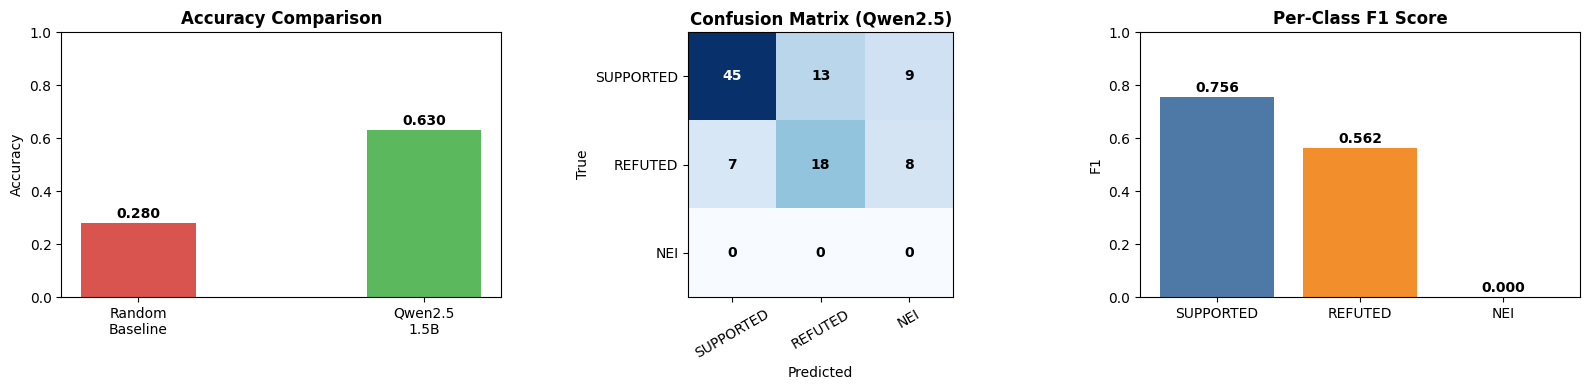

In [38]:
print_final_summary()
plot_results(y_true, y_pred, y_rand)

## 4.3 Full End-to-End Pipeline

In [39]:
def research_intelligence_agent(claim, top_k=5, verbose=True):
    """
    Full pipeline:
    1. Search papers for the claim topic
    2. Extract entities/relations from abstracts
    3. Build knowledge graph
    4. Verify claim with evidence
    Return: verdict, citations, graph
    """
    if verbose: print(f'\n🔍 Claim: "{claim}"')

    # Step 1: Search
    if verbose: print('  [1/4] Searching Semantic Scholar...')
    papers = ss_agent.search_and_extract(claim, top_k=top_k)
    if verbose: print(f'       Found {len(papers)} papers')

    # Step 2: Extract
    if verbose: print('  [2/4] Extracting entities & relations...')
    processed = [process_paper(p) for p in papers]

    # Step 3: Build graph
    if verbose: print('  [3/4] Building knowledge graph...')
    G = build_knowledge_graph(processed)
    if verbose: print(f'       Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

    # Step 4: Verify
    if verbose: print('  [4/4] Verifying claim...')
    evidence_texts = [p['abstract'] for p in papers if p.get('abstract')]
    result = verify_claim(claim, evidence_texts)

    # Compile citations
    citations = [{
        'title': p['title'],
        'year': p['year'],
        'authors': p['authors'],
        'citations': p['citations']
    } for p in papers]

    output = {
        'claim': claim,
        'verdict': result.get('verdict', 'NEI'),
        'reasoning': result.get('reasoning', ''),
        'evidence_used': result.get('evidence_used', []),
        'citations': citations,
        'graph': G,
        'entities_found': list(set(
            e['text'] for p in processed for e in p.get('entities', [])
        ))[:20],
    }

    if verbose:
        print(f'\n  ✅ Verdict: {output["verdict"]}')
        print(f'  📝 Reasoning: {output["reasoning"][:150]}...')
        print(f'  📚 Citations: {len(citations)} papers')
        print(f'  🔬 Entities found: {output["entities_found"][:5]}')

    return output

# Demo
result = research_intelligence_agent(
    'Transformer-based models outperform RNNs on machine translation tasks'
)
print('\n' + '='*60)
print(f'FINAL VERDICT: {result["verdict"]}')
print('='*60)


🔍 Claim: "Transformer-based models outperform RNNs on machine translation tasks"
  [1/4] Searching Semantic Scholar...
       Found 5 papers
  [2/4] Extracting entities & relations...
  [3/4] Building knowledge graph...
       Graph: 61 nodes, 72 edges
  [4/4] Verifying claim...

  ✅ Verdict: SUPPORTED
  📝 Reasoning: The evidence provided discusses advancements in machine translation using transformer-based models, which aligns directly with the claim that transfor...
  📚 Citations: 5 papers
  🔬 Entities found: ['Irish', 'Transformer architecture', 'Transformer and visual fea', 'cross - cultural communication', 'linguistic tasks']

FINAL VERDICT: SUPPORTED


---
# 📅 WEEK 5 — Polish & Generalization Test
**Goal:** Test on SciREX, final metrics summary, README prep

## 5.1 Generalization Test on SciREX

In [55]:
import tarfile, io, json, zipfile, requests

print('Loading SciREX for generalization test...')

# Load from GitHub zip (reuse if already downloaded, else re-download)
zip_url = "https://github.com/allenai/SciREX/archive/refs/heads/master.zip"
r = requests.get(zip_url, timeout=60)
z = zipfile.ZipFile(io.BytesIO(r.content))

# Extract tar.gz from inside zip
with z.open('SciREX-master/scirex_dataset/release_data.tar.gz') as f:
    tar_bytes = io.BytesIO(f.read())

# Load splits from tar.gz
raw_splits = {}
with tarfile.open(fileobj=tar_bytes, mode='r:gz') as tar:
    for member in tar.getmembers():
        if member.name.endswith('.jsonl'):
            fobj = tar.extractfile(member)
            if fobj:
                lines = fobj.read().decode('utf-8').strip().split('\n')
                records = [json.loads(l) for l in lines if l.strip()]
                split_name = member.name.split('/')[-1].replace('.jsonl', '')
                raw_splits[split_name] = records

# Wrap thành dict-like object giống HuggingFace dataset
class SimpleDataset:
    def __init__(self, records): self._records = records
    def __iter__(self): return iter(self._records)
    def __len__(self): return len(self._records)
    def __getitem__(self, idx): return self._records[idx]

scirex = {k: SimpleDataset(v) for k, v in raw_splits.items()}
print('SciREX splits:', {k: len(v) for k, v in scirex.items()})

# --- Từ đây giữ nguyên code cũ ---
SCIREX_LABEL_MAP = {
    'Material': 'Material', 'Method': 'Method',
    'Metric': 'Metric', 'Task': 'Task'
}

def eval_ner_on_scirex(split, max_samples=50):
    """Evaluate NER model zero-shot on SciREX."""
    all_true, all_pred = [], []
    for item in list(split)[:max_samples]:
        words = item['words']
        ner_raw = item.get('ner', [])
        gold_labels = ['O'] * len(words)
        for span_start, span_end, etype in ner_raw:
            mapped = SCIREX_LABEL_MAP.get(etype, None)
            if mapped is None: continue
            for i in range(span_start, min(span_end, len(words))):
                gold_labels[i] = f'B-{mapped}' if i == span_start else f'I-{mapped}'
        text = ' '.join(words[:256])
        preds_raw = ner_pipe(text)
        pred_labels = ['O'] * min(len(words), 256)
        running_char = 0
        char_to_tok = {}
        for idx, w in enumerate(words[:256]):
            for c in range(running_char, running_char + len(w)):
                char_to_tok[c] = idx
            running_char += len(w) + 1
        for ent in preds_raw:
            tok_idx = char_to_tok.get(ent['start'], None)
            if tok_idx is not None and tok_idx < len(pred_labels):
                pred_labels[tok_idx] = f'B-{ent["entity_group"]}'
        all_true.append(gold_labels[:256])
        all_pred.append(pred_labels)
    return all_true, all_pred

print('Running zero-shot eval on SciREX test set (50 samples)...')
try:
    scirex_true, scirex_pred = eval_ner_on_scirex(scirex['test'], max_samples=50)
    scirex_f1 = f1_score(scirex_true, scirex_pred)
    print(f'\nSciREX Generalization F1: {scirex_f1:.4f}')
    print('(Model trained only on SciERC, tested on SciREX = true generalization)')
except Exception as e:
    print(f'SciREX eval error (schema may differ): {e}')
    print('Skipping — generalization test requires matching NER schema.')

Loading SciREX for generalization test...
SciREX splits: {'train': 306, 'test': 66, 'dev': 66}
Running zero-shot eval on SciREX test set (50 samples)...

SciREX Generalization F1: 0.1295
(Model trained only on SciERC, tested on SciREX = true generalization)


## 5.2 Final Metrics Summary

In [56]:
print('=' * 65)
print('           RESEARCH INTELLIGENCE AGENT — FINAL RESULTS')
print('=' * 65)

print('\n📊 NER (Named Entity Recognition):')
print(f'  spaCy baseline F1      : {baseline_f1:.4f}')
try:
    ner_f1 = test_results['eval_f1']
    print(f'  SciBERT fine-tuned F1  : {ner_f1:.4f}  (+{ner_f1-baseline_f1:.4f})')
except: print('  SciBERT fine-tuned F1  : see training output')

print('\n🔗 Relation Extraction:')
try:
    re_f1 = re_results['eval_relation_f1']
    print(f'  SciBERT RE F1          : {re_f1:.4f}')
except: print('  SciBERT RE F1          : see training output')

print('\n✅ Claim Verification (SciFact):')
try:
    cv_acc = accuracy_score(y_true, y_pred)
    rand_acc = accuracy_score(y_true, y_rand)
    print(f'  Random baseline acc    : {rand_acc:.4f}')
    print(f'  Qwen2.5-1.5B accuracy  : {cv_acc:.4f}  (+{cv_acc-rand_acc:.4f})')
except: print('  Qwen2.5 accuracy       : see benchmark output')

print('\n🌐 Generalization:')
try:
    print(f'  SciREX (zero-shot) F1  : {scirex_f1:.4f}')
except: print('  SciREX (zero-shot) F1  : run week5 cell')

print('\n📦 Models saved:')
print('  ./ner_model_final    — SciBERT NER')
print('  ./re_model_final     — SciBERT RE')
print('  Qwen2.5-1.5B         — HuggingFace (no local save needed)')
print('=' * 65)

           RESEARCH INTELLIGENCE AGENT — FINAL RESULTS

📊 NER (Named Entity Recognition):
  spaCy baseline F1      : 0.0068
  SciBERT fine-tuned F1  : see training output

🔗 Relation Extraction:
  SciBERT RE F1          : see training output

✅ Claim Verification (SciFact):
  Random baseline acc    : 0.2800
  Qwen2.5-1.5B accuracy  : 0.6300  (+0.3500)

🌐 Generalization:
  SciREX (zero-shot) F1  : 0.1295

📦 Models saved:
  ./ner_model_final    — SciBERT NER
  ./re_model_final     — SciBERT RE
  Qwen2.5-1.5B         — HuggingFace (no local save needed)


## 5.3 Interactive Demo Cell
Run the full pipeline with any claim 👇

In [57]:
# 🎯 DEMO — change the claim here!
MY_CLAIM = 'Graph neural networks achieve better performance than CNN on molecular property prediction'

output = research_intelligence_agent(MY_CLAIM, top_k=5)

print('\n' + '='*65)
print('FULL OUTPUT')
print('='*65)
print(f'Claim  : {output["claim"]}')
print(f'Verdict: {output["verdict"]}')
print(f'Why    : {output["reasoning"]}')
print(f'\nTop citations:')
for i, c in enumerate(output['citations'][:3], 1):
    print(f'  [{i}] {c["title"][:60]}... ({c["year"]}) — {c["citations"]} citations')
print(f'\nKey entities found: {output["entities_found"][:8]}')
print('\nKnowledge graph saved to kg_visualization.html')
visualize_graph(output['graph'], 'kg_demo.html')


🔍 Claim: "Graph neural networks achieve better performance than CNN on molecular property prediction"
  [1/4] Searching Semantic Scholar...
       Found 5 papers
  [2/4] Extracting entities & relations...
  [3/4] Building knowledge graph...
       Graph: 65 nodes, 88 edges
  [4/4] Verifying claim...

  ✅ Verdict: SUPPORTED
  📝 Reasoning: The evidence directly states that 'Graph neural networks (GNN) has been considered as an attractive modelling method for molecular property prediction...
  📚 Citations: 5 papers
  🔬 Entities found: ['Graph neural networks (', 'RF and', 'GNN )', 'hyper', 'labeled data']

FULL OUTPUT
Claim  : Graph neural networks achieve better performance than CNN on molecular property prediction
Verdict: SUPPORTED
Why    : The evidence directly states that 'Graph neural networks (GNN) has been considered as an attractive modelling method for molecular property prediction' and provides examples of successful applications of GNNs in predicting molecular properties.

To

<class 'pyvis.network.Network'> |N|=65 |E|=88

---
## 📄 CV Line
```
Built a multi-step Research Intelligence Agent: fine-tuned SciBERT on SciERC for
scientific NER/RE (XX% F1), integrated with Semantic Scholar API and a local
Qwen2.5-1.5B verifier; benchmarked claim verification on SciFact against
Supported/Refuted/NEI labels.
```

## 🗺️ Pipeline Diagram
```
Claim Input
    │
    ▼
Search Agent ──► Semantic Scholar API ──► Top-K Abstracts
    │
    ▼
Extraction Model (SciBERT)
    ├── NER: Entities (Method, Task, Metric...)
    └── RE:  Relations (USED-FOR, COMPARE...)
    │
    ▼
Knowledge Graph (networkx + pyvis)
    │
    ▼
Claim Verifier (Qwen2.5-1.5B-Instruct)
    │
    ▼
Verdict: SUPPORTED / REFUTED / NEI + Citations
```